# Rank-based for finding the matching btw merfish cell to the snRNAseq cells
- do we also impute the original values?

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")
mesh_CD = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCD_ccf_v1_250102 2.obj")
mesh_CV = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/subCV_ccf_v1_250102 2.obj")
allmeshes = [mesh_LC,mesh_CD,mesh_CV]

# load data

In [3]:
import glob, os, sys
from scipy.io import mmread
import sys
sys.path.append('../func/')
from imputations import *

In [4]:

filepath = '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/'
glob.glob(filepath+'/*.h5ad')

['/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/AIBS_LC_NA_raw_CPM.h5ad',
 '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/AIND_LC_batch2_241118_qcv0.h5ad',
 '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/bruchas_LC_NA_raw_CPM.h5ad',
 '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/schwarz_LC_NA_raw_CPM.h5ad',
 '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/snRNAseq_LCNE.h5ad',
 '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN.h5ad',
 '/allen/aind/scratch/shuonan.chen/LC_scRNAseq/conversion_files/ssv4_LC_NA_raw_CPM.h5ad']

### new way of loading the data

# use the batch normalized ones

In [5]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

In [14]:
adata_foo.layers['BN'].shape

(4895, 2001)

In [8]:
adata_sc.shape

(4895, 2001)

# load merfish too
(these are normalized already..?)

In [6]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 
print(adata_mer.X.max())# do not normalize again.

0.13489233


In [7]:
adata_mer.shape

(2651, 125)

### re-run the leiden for ONLY these 3k cells

In [9]:
adata_mer.obsm

AxisArraysView with keys: X_scVI, X_umap, spatial

In [10]:
umap_random_state = 307

sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)
sc.tl.leiden(adata_mer, resolution=1,   key_added = 'new leiden!',random_state=umap_random_state)

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)
/scratch/fast/66059/ipykernel_2428208/3355728225.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_mer, resolution=1,   key_added = 'new leiden!',random_state=umap_random_state)


In [11]:
adata_mer.obsm

AxisArrays with keys: X_scVI, X_umap, spatial

In [18]:
with plt.rc_context({"figure.figsize": (6,3)}):
    ax = sc.pl.umap(adata_mer,color=['leiden', 'new leiden!'],
               cmap='Reds',ncols=3, show = False,
               use_raw = False)
    for a in ax:
        a.set_aspect('equal')

In [19]:
with plt.rc_context({"figure.figsize": (5,3)}):        
    ax = sc.pl.umap(adata_mer,color=intersted_genes,
               cmap='Reds',ncols=3, show = False,
               use_raw = False)
    for a in ax:
        a.set_aspect('equal')

# RUN impute!

In [20]:
# n_hvg is essentially how many genes you want to imput. 
adata_mer_imputed = impute_mer_data(adata_sc, adata_mer, k=200, n_hvg=None)

In [21]:
adata_mer_imputed.shape

(2651, 2001)

# okay now we run teh clustering kind of thing

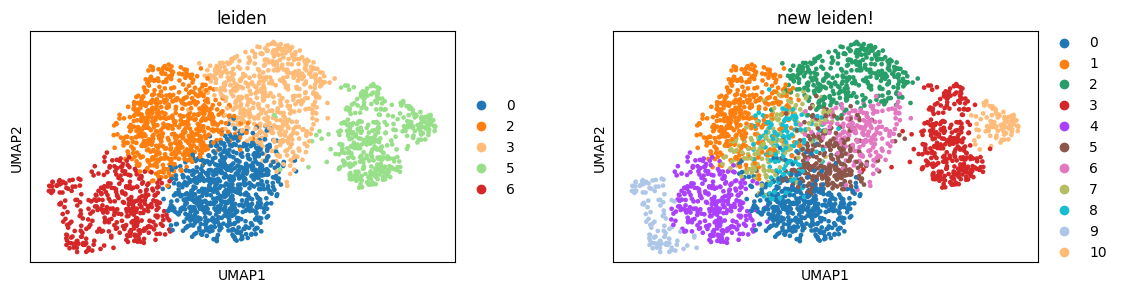

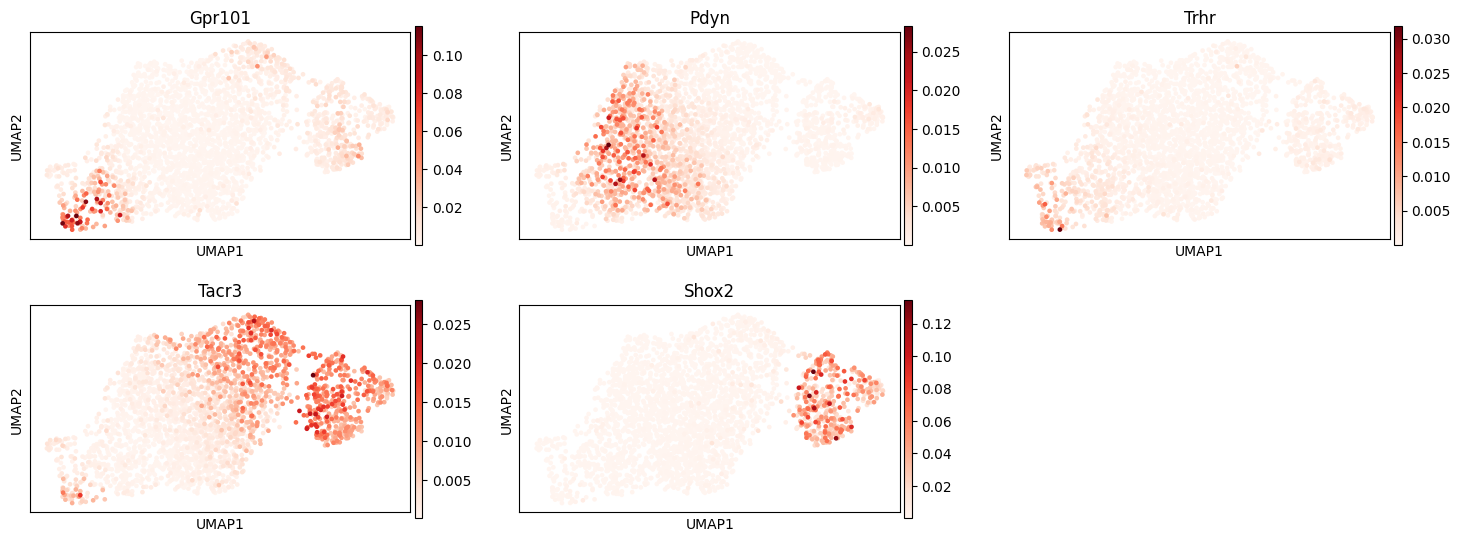

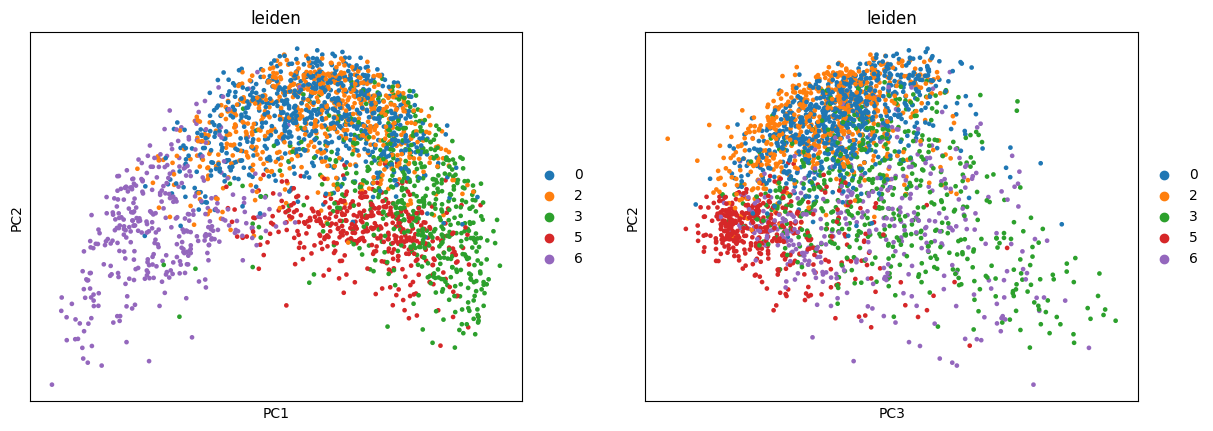

In [22]:
sc.tl.pca(adata_mer_imputed)
sc.pl.pca(adata_mer_imputed,color=['leiden','leiden'], dimensions = [(0,1),(2,1)])

In [23]:
adata_mer_imputed.varm

AxisArrays with keys: PCs

In [24]:
df_loadings = pd.DataFrame(adata_mer_imputed.varm['PCs'], index=adata_mer_imputed.var_names)

In [25]:
# top T genes with PC1.. 
T = 10
adata_mer_imputed.var_names[np.argsort(df_loadings[0])[::-1][:T]]  

Index(['Hs6st3', 'Gpc6', 'Kcnab1', 'Dpp10', 'Dab1', 'Dgkb', 'B3galt1',
       'Sema6d', 'Pcdh7', 'Mctp1'],
      dtype='object')

In [26]:
adata_mer_imputed.shape

(2651, 2001)

In [27]:
(adata_mer.X[:,adata_mer.var_names =='Dbh'] == adata_mer_imputed.X[:,adata_mer_imputed.var_names =='Dbh']).all()

np.True_

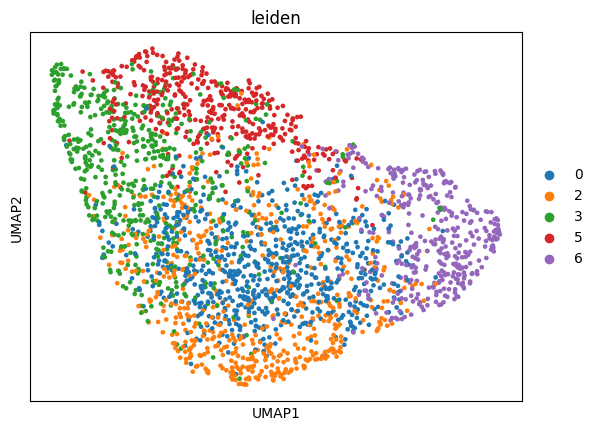

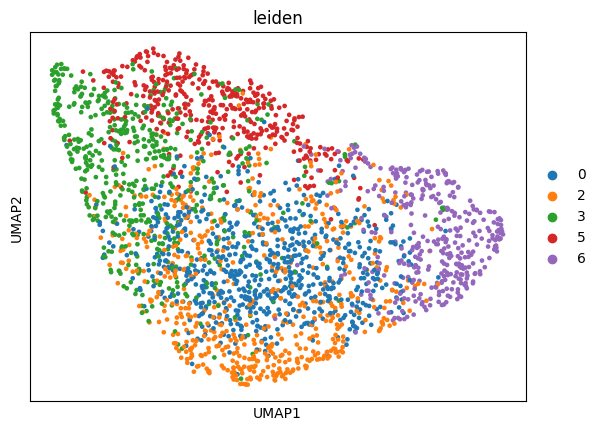

In [29]:

sc.pp.neighbors(adata_mer_imputed)
sc.tl.umap(adata_mer_imputed)
# sc.pl.umap(adata_mer_imputed,color=["leiden"],)

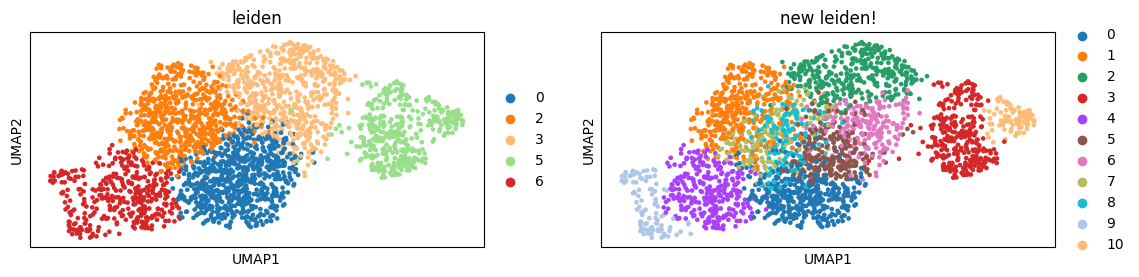

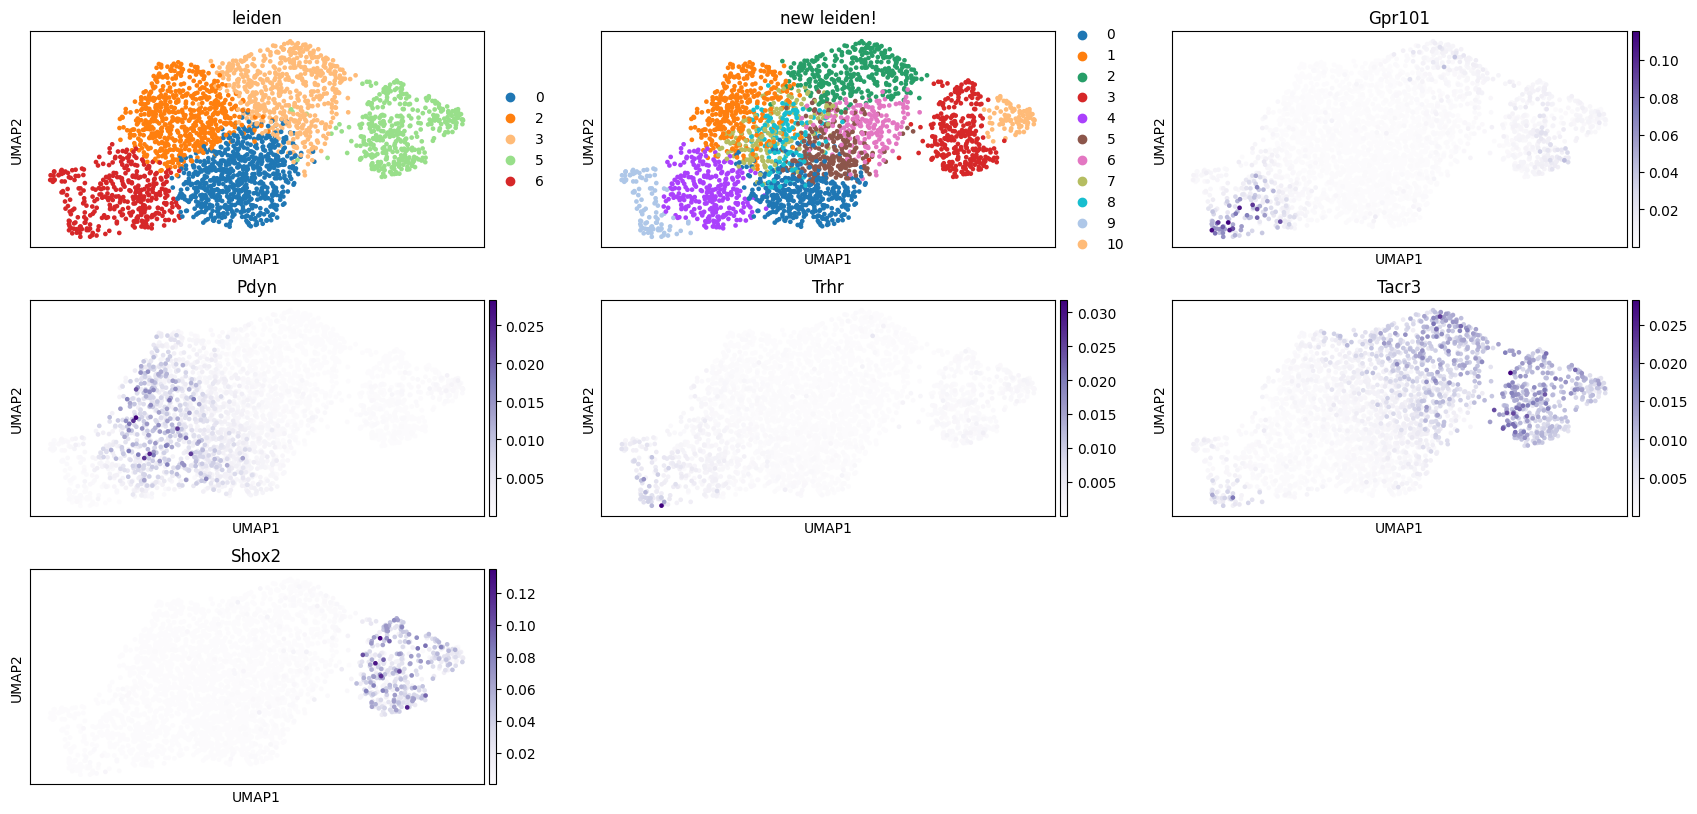

In [31]:
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,color=['leiden', 'new leiden!',]+intersted_genes,
           cmap='Purples',ncols=3)


In [32]:
adata_mer_imputed.shape

(2651, 2001)

In [33]:
adata_sc.shape

(4895, 2001)

# add the imputed values on the original umap 

In [34]:
def replace_imputedvalues(adata_mer,adata_mer_imputed, genelist):
    for g in genelist:
        adata_mer.obs[f'imput_{g}'] = (
            adata_mer_imputed[:, g].X.toarray().flatten() 
            if hasattr(adata_mer_imputed.X, "toarray") 
            else np.array(adata_mer_imputed[:, g].X.flatten()))
    return(adata_mer)

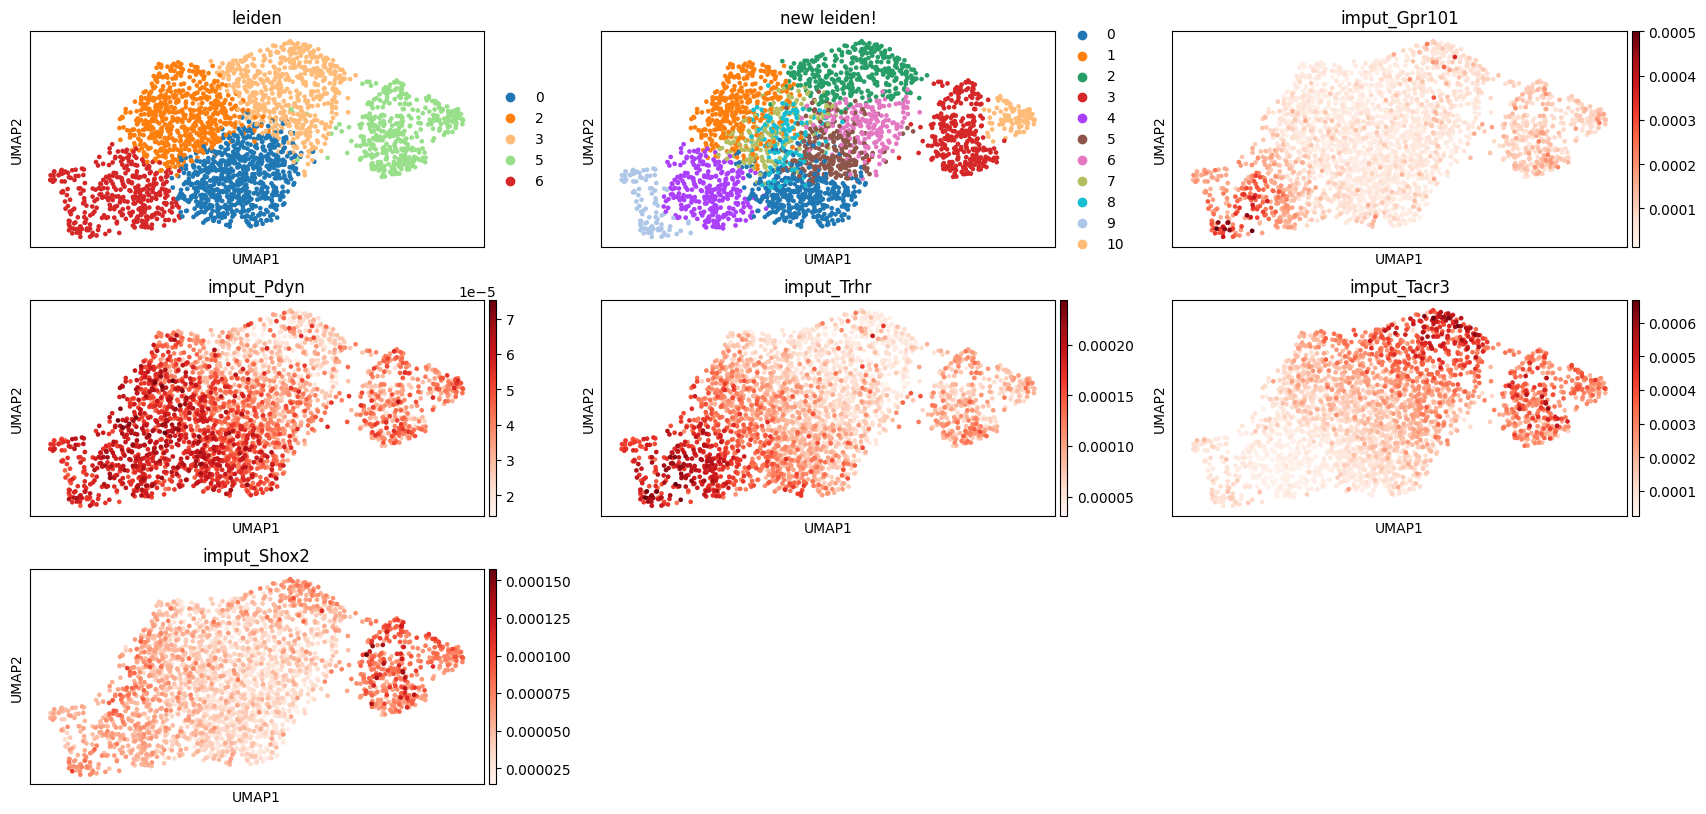

In [39]:

adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed, intersted_genes)
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = ['leiden', 'new leiden!']+[f'imput_{g}' for g in intersted_genes],           
           cmap='Reds',ncols=3)


# so how to validate this imputation result? 
- note sure at this point

In [40]:
# confirm all the merfish genes are kept (it should be since we took the union)
np.array([(a in (adata_mer_imputed.var_names)) for a in (adata_mer.var_names)]).sum()

np.int64(125)

# check their spatial distributions

In [41]:
import matplotlib.pyplot as plt

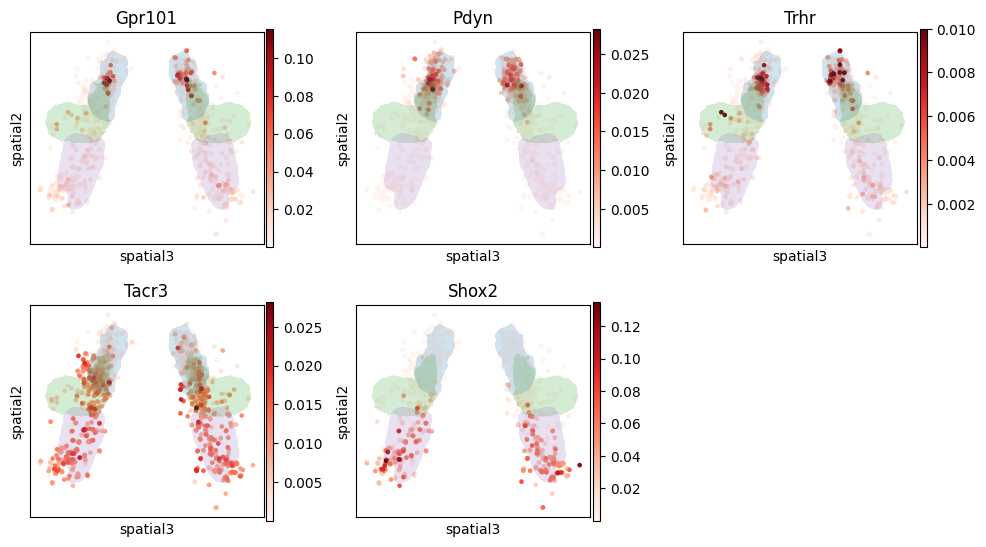

In [45]:
vmaxlist = list(np.max(adata_mer[:,intersted_genes].X, 0))
vmaxlist[2] = 0.01
with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer, dimensions = (2, 1),basis="spatial", cmap ='Reds',
                         vmax = vmaxlist,
                         color=intersted_genes,ncols =3, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
#     plt.tight_layout()
#     fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    fig.suptitle('original!!')
    plt.show()    
    

/scratch/fast/66059/ipykernel_2428208/422356047.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


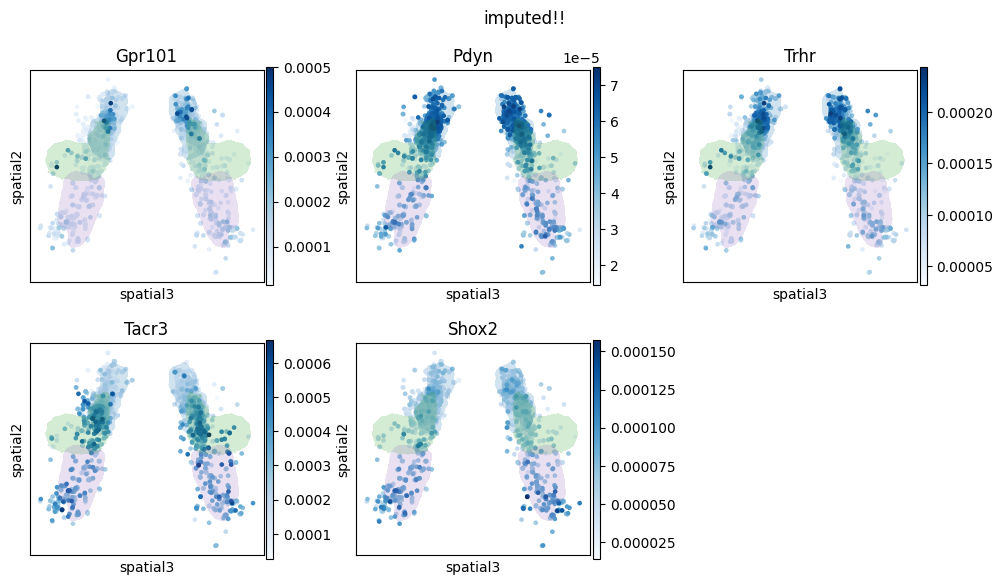

In [46]:

with plt.rc_context({"figure.figsize": (3,3)}):    
    ax = sc.pl.embedding(adata_mer_imputed, dimensions = (2, 1),basis="spatial", cmap ='Blues',
                         color=intersted_genes,ncols =3, show=False)    
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .2, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .2, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .2, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig.tight_layout()
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    fig.suptitle('imputed!!')
    plt.show()    

# similarly, these genes are found to be highly correlated with the arc in PC sapce 

In [54]:
# negative set 
pca_arc_genes =['Dab1',
 'Gpc6',
 'Fat3',
 'Chsy3',
 'B3galt1',
 'Hs6st3',
 'Parm1',
 'Tbc1d4',
 'Thsd7b',
 'Glra2',
 'Arhgap15',
 'Dach1',
 'Kcnab1',
 'Neto1',
 'Plxna4',
 'Clstn2',
 'Efna5',
 'Kalrn',
 'Slit2',
 'Gabra2']

In [50]:
pca_arc_genes =['Epha6',
 'Htr2c',
 'Lrrc7',
 'Robo1',
 'Pantr1',
 'Alcam',
 'Lnx1',
 'Ncam2',
 'Inpp4b',
 'Cntnap5b',
 'Cdh20',
 'Cntnap5a',
 'Cdh18',
 'Gm20646',
 'Col18a1',
 'Setbp1',
 'Alk',
 'Lrrtm4',
 'Dip2c',
 'Slit1']


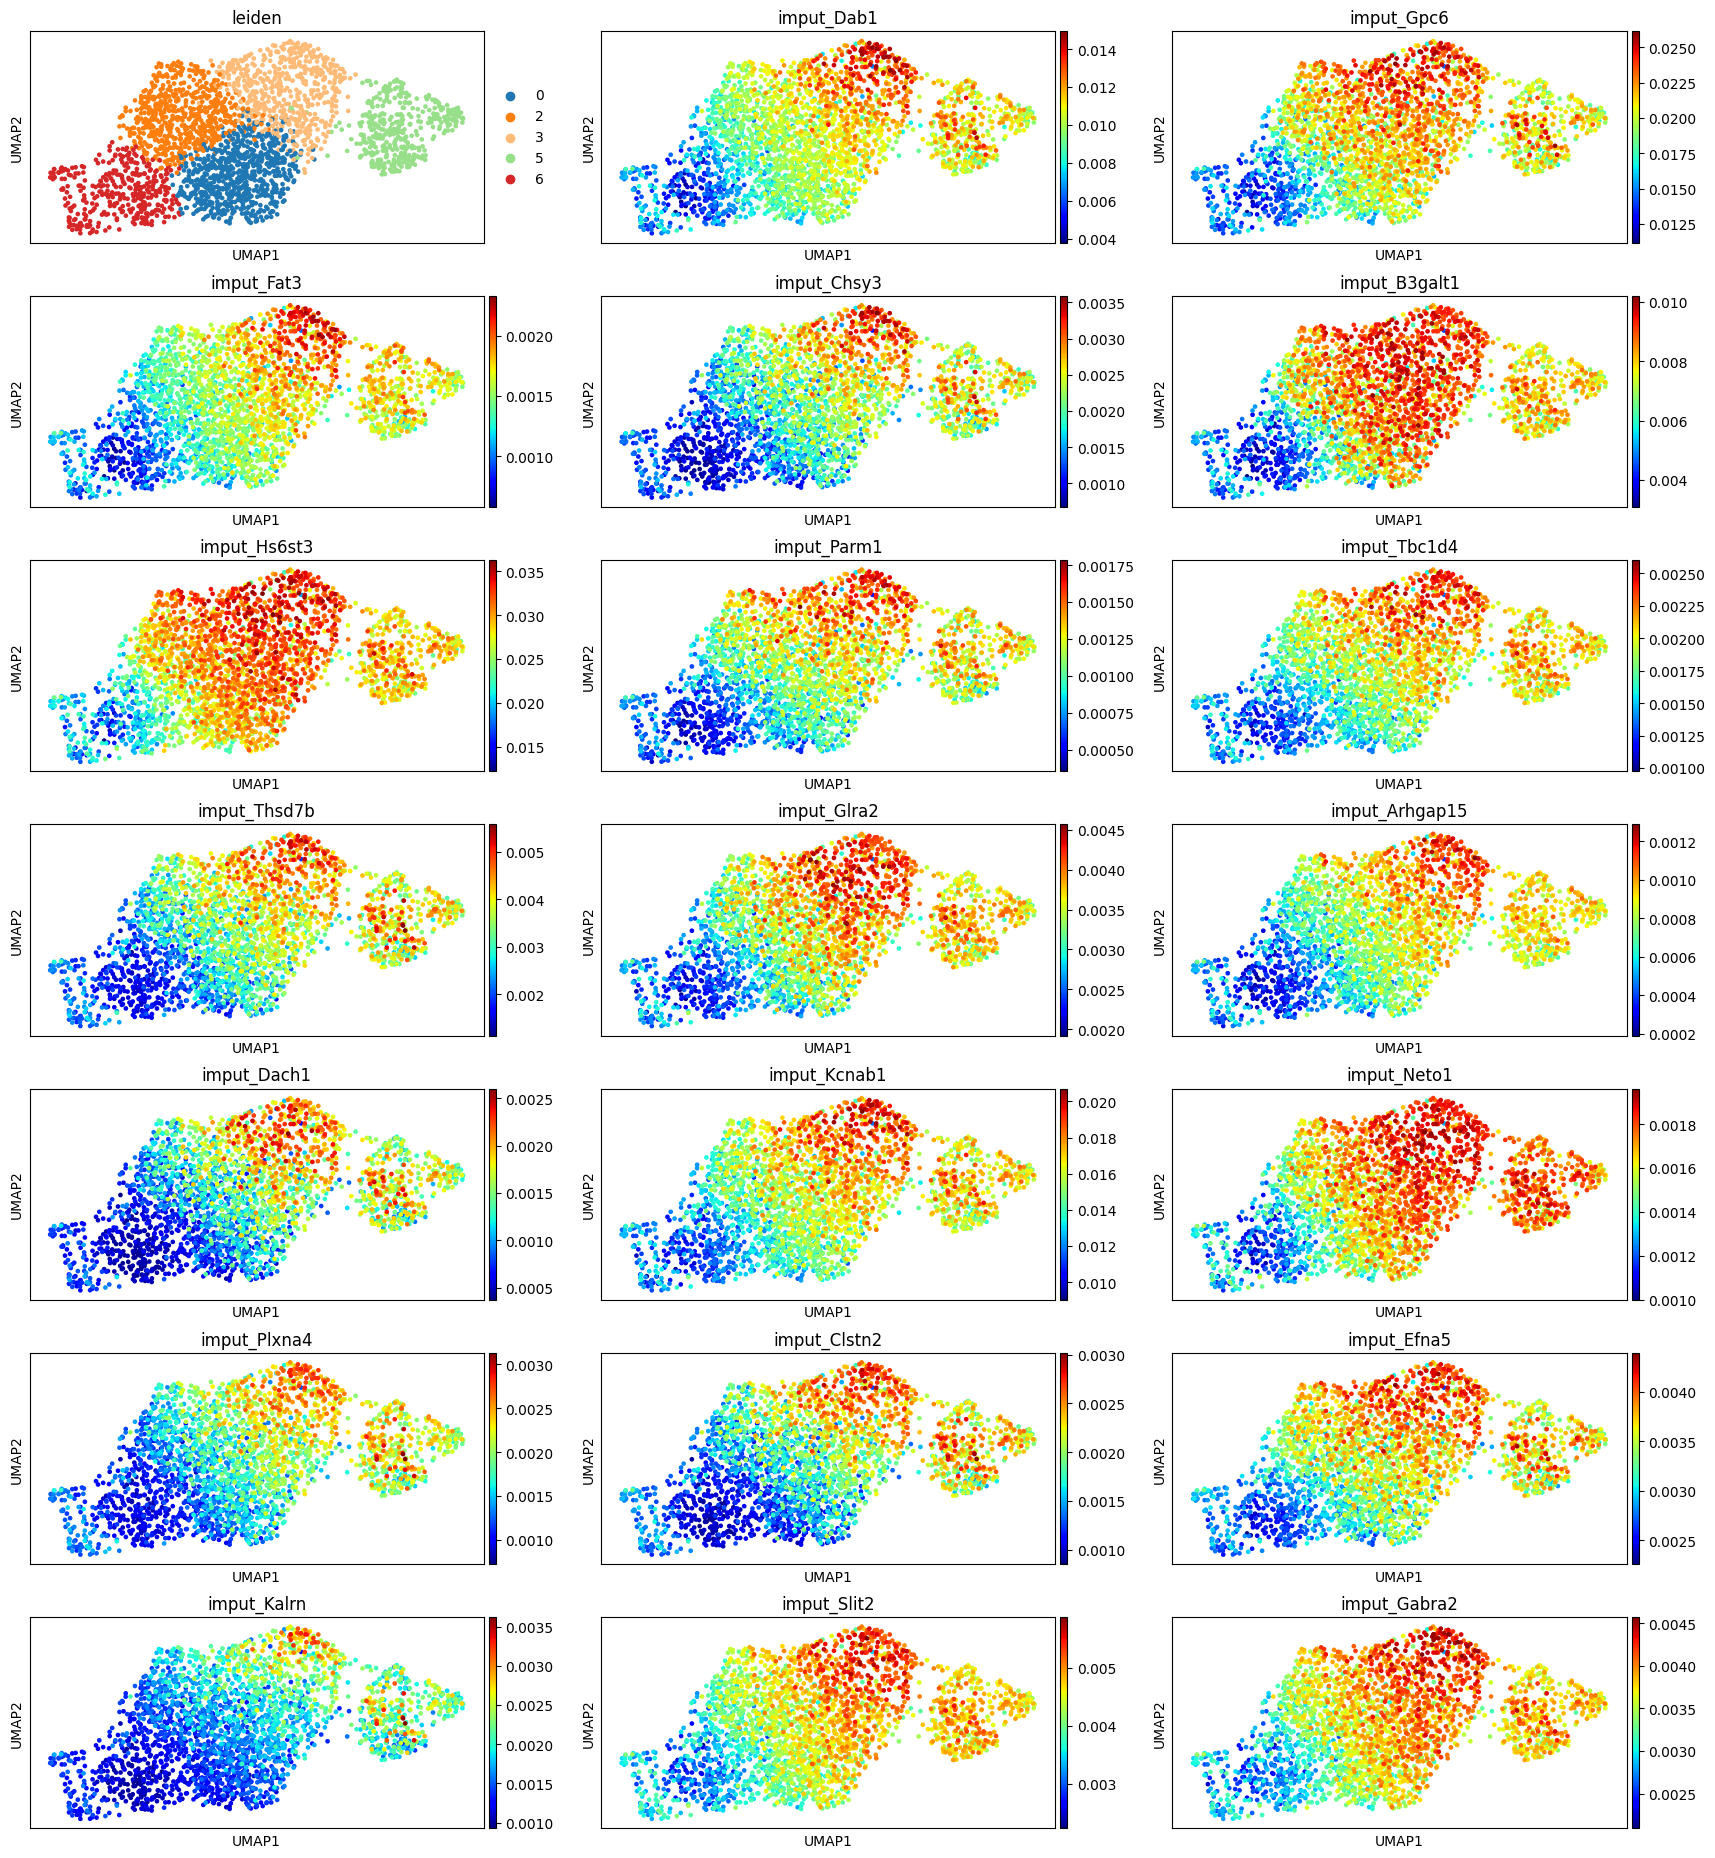

In [55]:
adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed, pca_arc_genes)
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = ['leiden']+[f'imput_{g}' for g in pca_arc_genes],           
           cmap='jet',ncols=3)

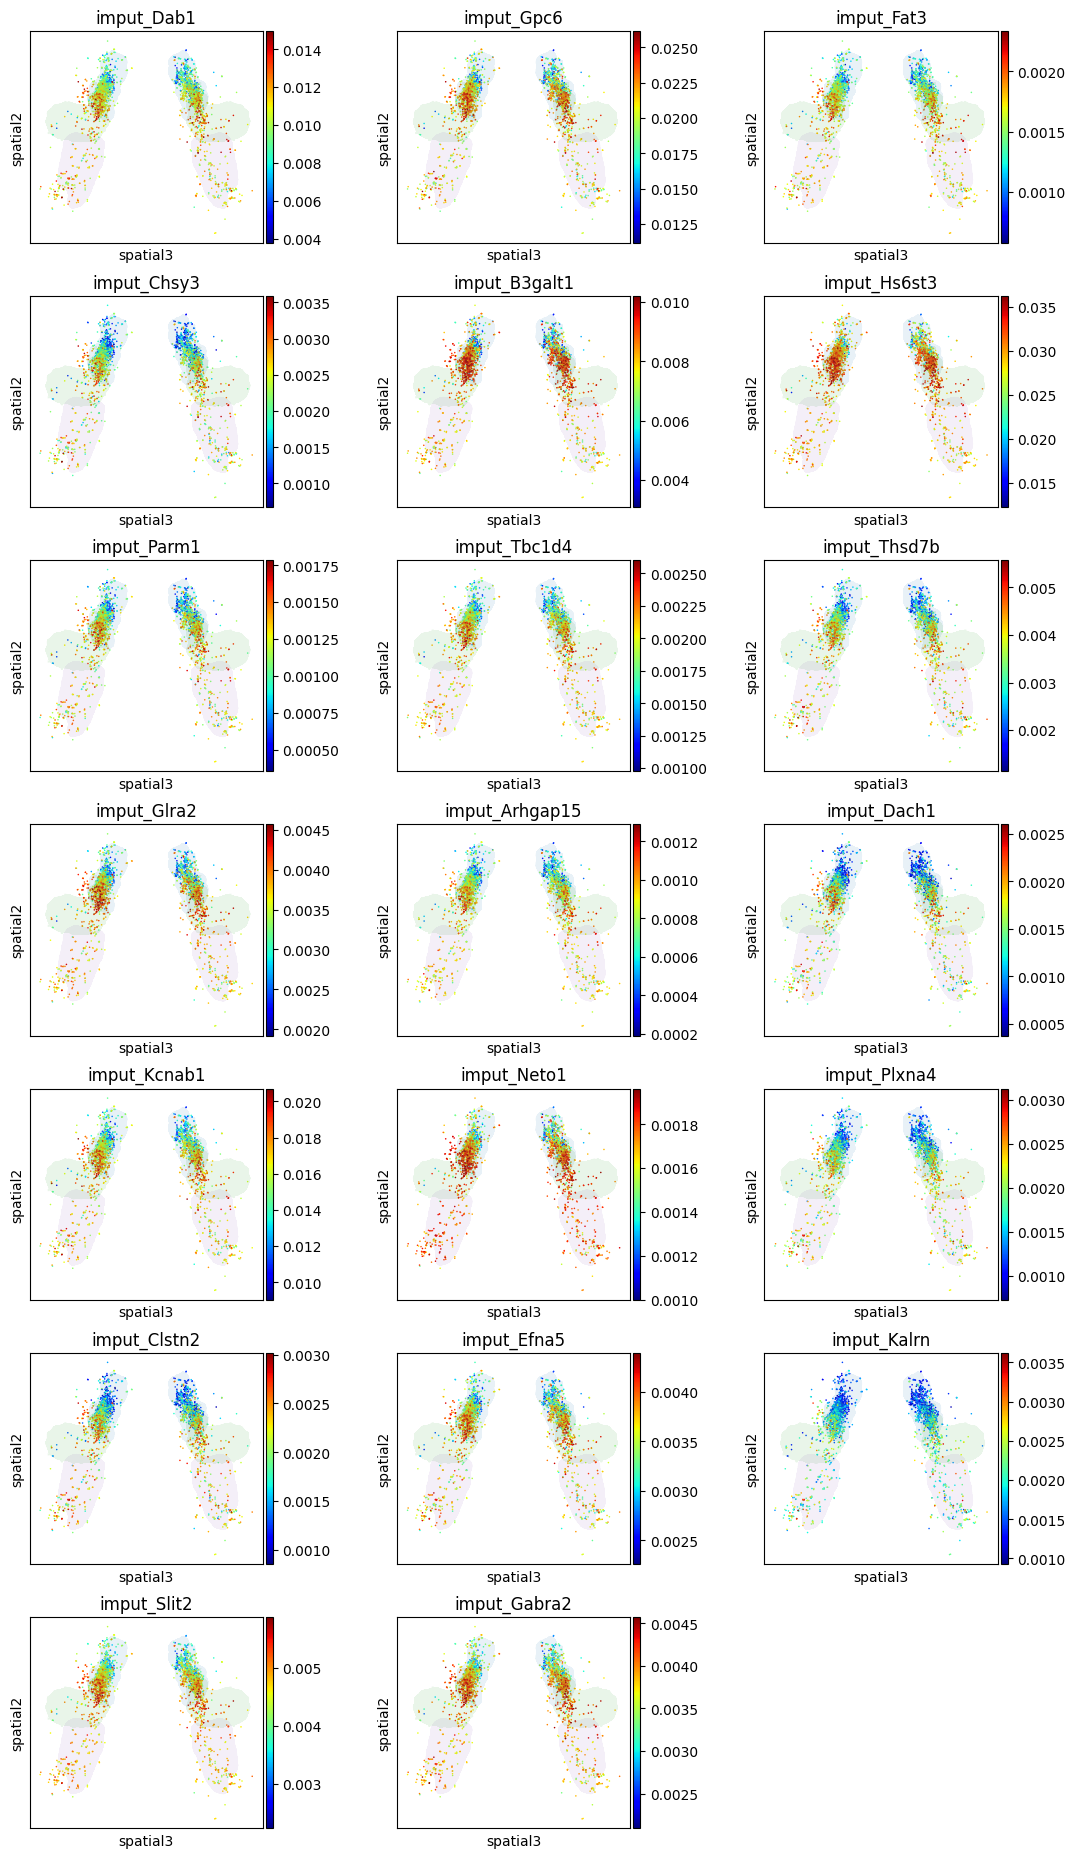

In [56]:
with plt.rc_context({"figure.figsize": (3.5,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(2,1),
           color = [f'imput_{g}' for g in pca_arc_genes],           
           cmap='jet',ncols=3, size = 5, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    # fig.suptitle('fii')
    plt.show()    

### (sagital check)

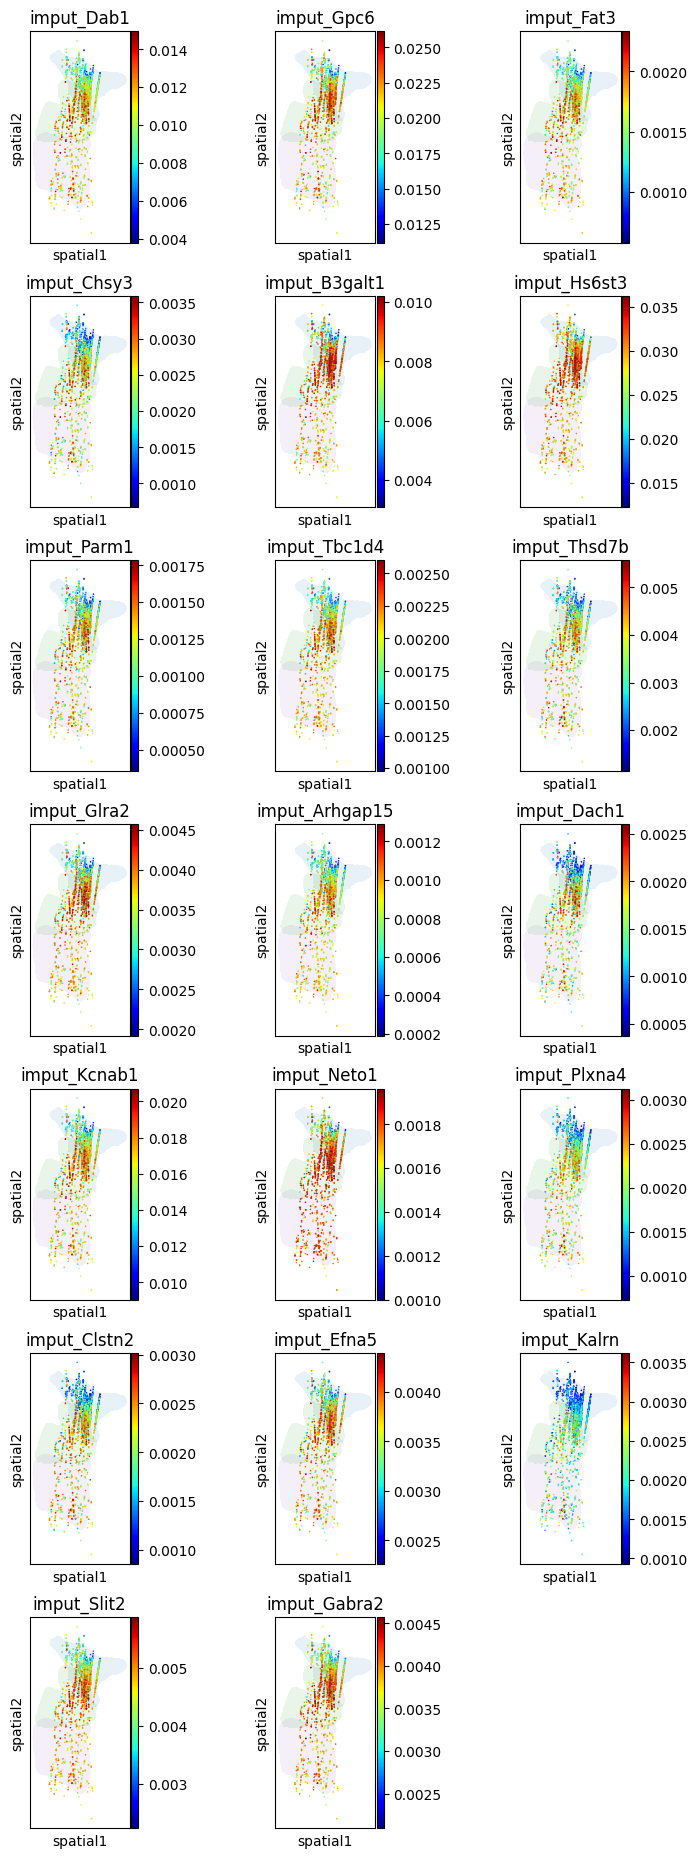

In [57]:
with plt.rc_context({"figure.figsize": (2,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(0,1),
           color = [f'imput_{g}' for g in pca_arc_genes],           
           cmap='jet',ncols=3, size =5, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    # fig.suptitle('fii')
    plt.show()    

# plot some gradient genes that are already found from PCA (snRNAseq)

In [ ]:
pos_grad_genes_list = ['Robo1','Il1rapl1','Htr2c','Alcam','Inpp4b']
neg_grad_genes_list = ['Dpp10','Dab1','Dach1']

## gradient genes in umap

In [ ]:

adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed, pos_grad_genes_list)
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = ['leiden']+[f'imput_{g}' for g in pos_grad_genes_list],           
           cmap='jet',ncols=3)

    sc.pl.umap(adata_mer_imputed,color=['leiden']+pos_grad_genes_list,
           cmap='jet',ncols=3)


In [ ]:
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = [f'imput_{g}' for g in pos_grad_genes_list],           
           cmap='jet',ncols=3)


In [ ]:
adata_mer = replace_imputedvalues(adata_mer,adata_mer_imputed, neg_grad_genes_list)
with plt.rc_context({"figure.figsize": (6,3)}):
    sc.pl.umap(adata_mer,
           color = [f'imput_{g}' for g in neg_grad_genes_list],           
           cmap='jet',ncols=3)

    sc.pl.umap(adata_mer_imputed,color=neg_grad_genes_list,
           cmap='jet',ncols=3)


## gradient genes in space

### (coronal check)

In [ ]:

ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(2,1),
       color = ['leiden']+[f'imput_{g}' for g in pos_grad_genes_list],           
       cmap='jet',ncols=3, show = False)
for a in ax:
    a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    a.invert_yaxis()
    a.set_aspect('equal')
fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
fig.suptitle('fii')
plt.show()    




In [ ]:
with plt.rc_context({"figure.figsize": (3.5,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(2,1),
           color = [f'imput_{g}' for g in pos_grad_genes_list[:3]],           
           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    # fig.suptitle('fii')
    plt.show()    

### (sagital check)

In [ ]:
with plt.rc_context({"figure.figsize": (2,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(0,1),
           color = [f'imput_{g}' for g in pos_grad_genes_list[:3]],           
           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    # fig.suptitle('fii')
    plt.show()    

## negatie ones, coronal

In [ ]:
with plt.rc_context({"figure.figsize": (3.5,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(2,1),
           color = [f'imput_{g}' for g in neg_grad_genes_list],           
           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    # fig.suptitle('fii')
    plt.show()    

### (sagital check)

In [ ]:
with plt.rc_context({"figure.figsize": (2,3)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(0,1),
           color = [f'imput_{g}' for g in neg_grad_genes_list],           
           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    # fig.suptitle('fii')
    plt.show()    

In [ ]:

ax = sc.pl.embedding(adata_mer,basis='spatial',dimensions=(2,1),sort_order=True,
       color = [f'imput_{g}' for g in neg_grad_genes_list],           
       cmap='jet',ncols=3, show = False)
for a in ax:
    a.triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    a.triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    a.triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
    a.invert_yaxis()
    a.set_aspect('equal')
fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
fig.suptitle('fii')
plt.show()    




## negative ones, sagital

In [ ]:
with plt.rc_context({"figure.figsize": (3,6)}):
    ax= sc.pl.embedding(adata_mer,basis='spatial',dimensions=(0,1),
           color = [f'imput_{g}' for g in neg_grad_genes_list],           
           cmap='jet',ncols=3, show = False)
    for a in ax:
        a.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        a.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        a.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        a.invert_yaxis()
        a.set_aspect('equal')
    fig = ax[0].figure  # assuming ax is a list of axes from your sc.pl.embedding call
    fig.suptitle('fii')
    plt.show()    

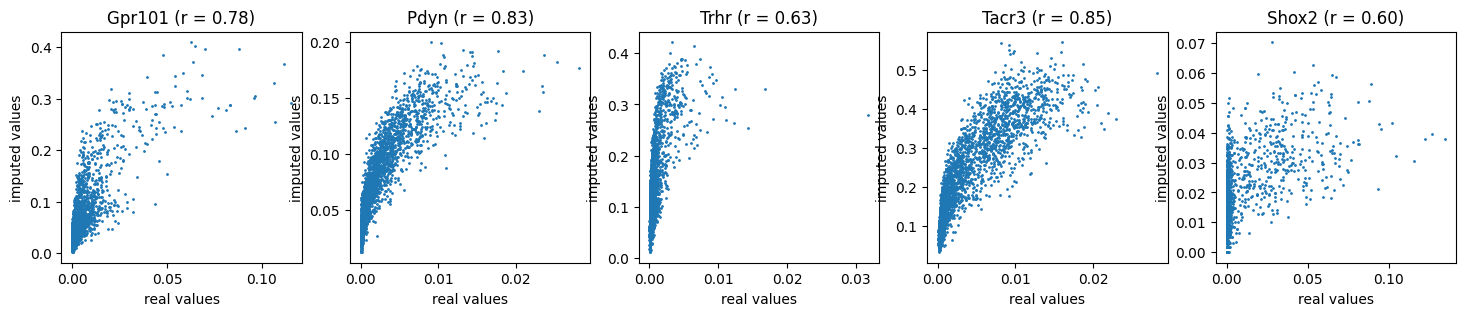

In [101]:
plt.figure(figsize = (18,3))
for i,tested_gene in enumerate(intersted_genes):
    plt.subplot(1,5,i+1)
    x = adata_mer[:, tested_gene].X.flatten()
    y = adata_mer.obs['imput_' + tested_gene].values
    plt.scatter(x, y, s=1)
    
    corr_coef = np.corrcoef(x, y)[0, 1]    
    plt.title(f"{tested_gene} (r = {corr_coef:.2f})")
    plt.ylabel('imputed values')
    plt.xlabel('real values')
plt.show()    

In [ ]:
adata_mer_imputed.write('/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/data/adata_mer_imputed_all.h5ad')